# Analysis

In [ ]:
import os

import matplotlib.pyplot as plt
import mpltern
import numpy as np
import pandas as pd

from analysis_helper import (
    MODELS,
    build_summary_table,
    canonical_prediction_frame,
    combined_multiclass_metrics,
    extract_curve_from_npy,
    load_ensemble_df,
    load_predictions_by_group,
    mean_prob_for_target,
    mean_probabilities,
    mean_probs_by_pred_class,
    mean_probs_by_true,
    plot_datasets_grid,
    plot_training_overview,
    predicted_distribution,
    resolve_ensemble_path,
    resolve_pred_col,
    summarize_validation_metrics,
    target_recall,
    to_class_series,
    merge_dataset_ensembles,
    DATASET_FIGURE_GROUPS,
)

# ========== BASE PATHS ==========
DATA_SHARE_DIR = "/Data_share" ## Replace with actual path to data share

# ========== MODEL OUTPUT DIRECTORIES ==========
POINTNET2_OUTPUT_ROOT = os.path.join(DATA_SHARE_DIR, "PointNet2", "Output")
DGCNN_OUTPUT_ROOT = os.path.join(DATA_SHARE_DIR, "DGCNN", "Output")

POINTNET2_RESULTS_DIR_LATEST = os.path.join(POINTNET2_OUTPUT_ROOT, "independent_test_batches")
DGCNN_RESULTS_DIR_LATEST = os.path.join(DGCNN_OUTPUT_ROOT, "independent_test_batches")
POINTNET2_TRAINING_DIR = os.path.join(POINTNET2_OUTPUT_ROOT, "training")
DGCNN_TRAINING_DIR = os.path.join(DGCNN_OUTPUT_ROOT, "training")

for path in [POINTNET2_RESULTS_DIR_LATEST, DGCNN_RESULTS_DIR_LATEST, POINTNET2_TRAINING_DIR, DGCNN_TRAINING_DIR]:
    if not os.path.isdir(path):
        raise FileNotFoundError(f"Required results folder not found: {path}")

PN_ROOT = POINTNET2_RESULTS_DIR_LATEST
DG_ROOT = DGCNN_RESULTS_DIR_LATEST

TABLE_MODEL_ROOTS = {
    "PointNet++": PN_ROOT,
    "DGCNN": DG_ROOT,
}

MODEL_ROOTS_FIGURES = {
    "PointNet++": PN_ROOT,
    "DGCNN": DG_ROOT,
}

# Results

## Figures

### Figure 3

Saved Figure 3 to figures/Figure_3.jpg


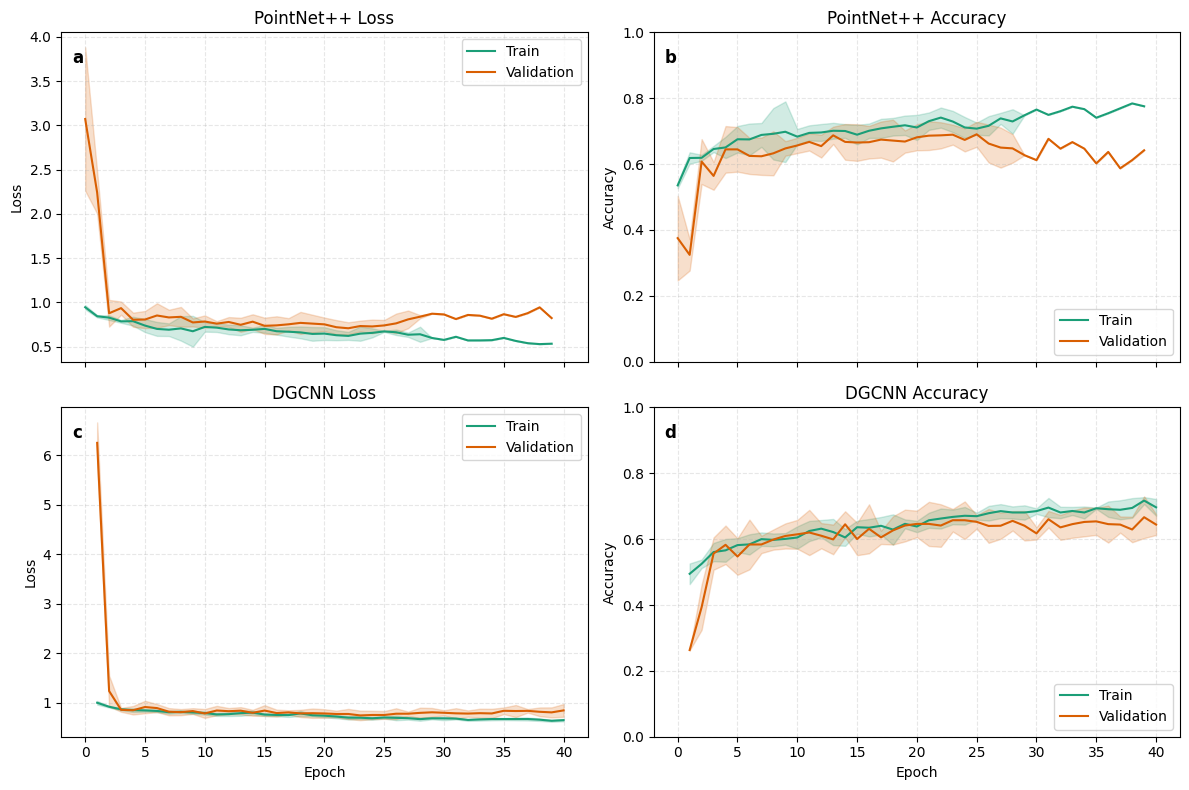

In [2]:
pn_metrics_latest, dg_metrics_latest = plot_training_overview(
    POINTNET2_TRAINING_DIR,
    DGCNN_TRAINING_DIR,
    figsize=(12, 8),
    save_path="figures/Figure_3.jpg",
    dpi=300,
)

### Figures 4 - 6

Saved Figure 4 to figures/Figure_4.jpg (figsize=6.83x6.83)


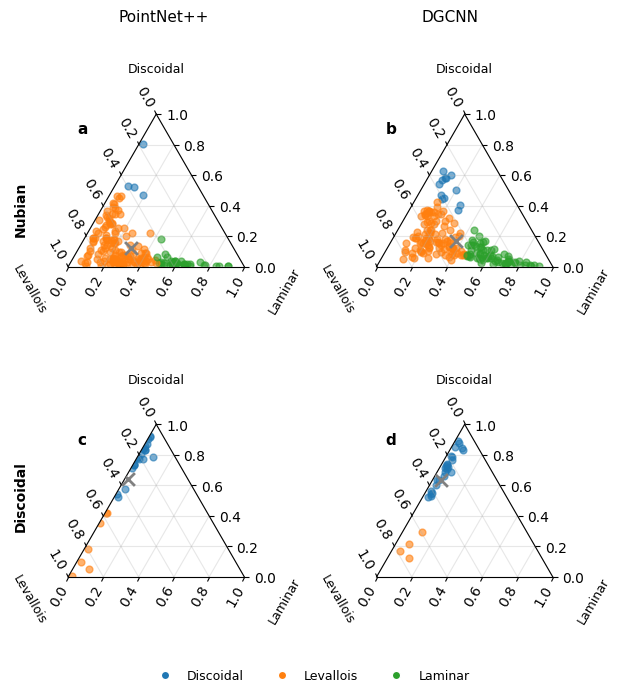

Saved Figure 5 to figures/Figure_5.jpg (figsize=9.40x9.40)


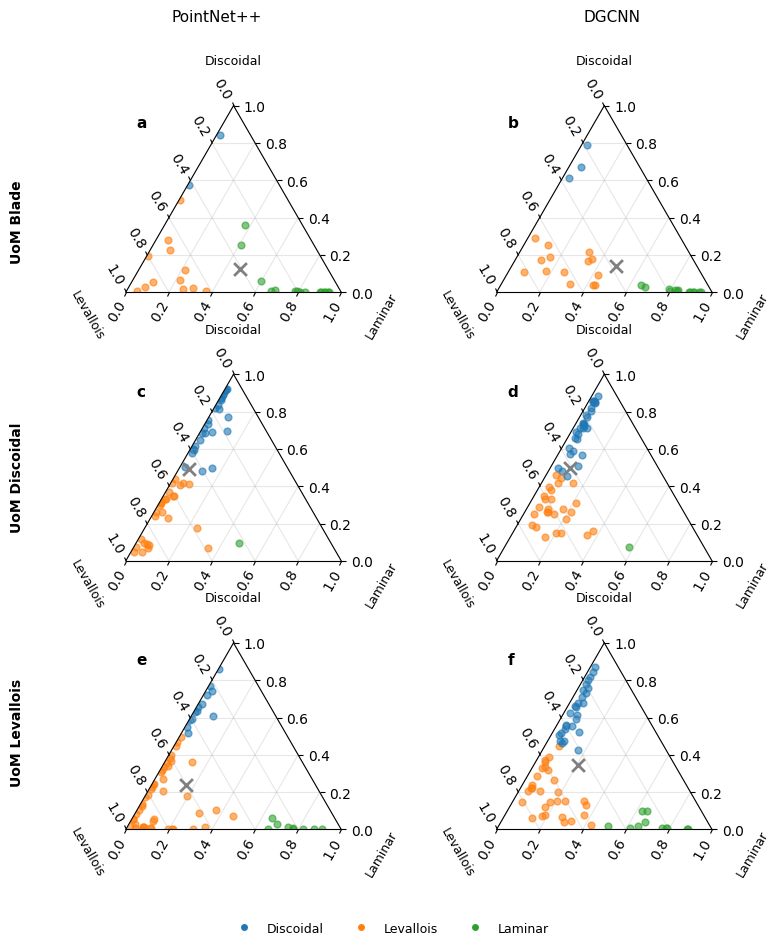

Saved Figure 6 to figures/Figure_6.jpg (figsize=6.83x3.75)


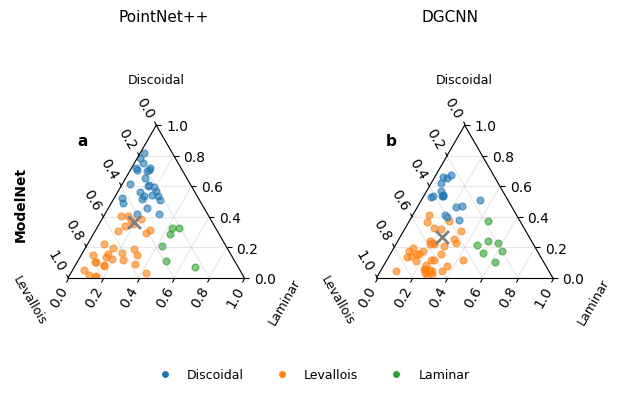

In [ ]:
import os

datasets_by_group = load_predictions_by_group(MODEL_ROOTS_FIGURES)
os.makedirs("figures", exist_ok=True)

reference_group = 2
reference_figsize = (8.6, 9.4)

fig_ref = plot_datasets_grid(DATASET_FIGURE_GROUPS[reference_group], datasets_by_group[reference_group], MODELS, figsize=reference_figsize)
if not fig_ref.axes:
    raise RuntimeError("Reference figure produced no axes")
ref_ax = fig_ref.axes[0]
ref_box = ref_ax.get_position()
# physical size (inches) of one subplot in the reference figure
target_ax_w_in = ref_box.width * reference_figsize[0]
target_ax_h_in = ref_box.height * reference_figsize[1]

import matplotlib.pyplot as plt
plt.close(fig_ref)

for group_idx in [1, 2, 3]:
    dataset_keys = DATASET_FIGURE_GROUPS[group_idx]

    fig_tmp = plot_datasets_grid(dataset_keys, datasets_by_group[group_idx], MODELS, figsize=(1.0, 1.0))
    if not fig_tmp.axes:
        raise RuntimeError(f"Temporary figure for group {group_idx} produced no axes")
    tmp_ax = fig_tmp.axes[0]
    tmp_box = tmp_ax.get_position()
    frac_w = tmp_box.width
    frac_h = tmp_box.height
    plt.close(fig_tmp)

    req_fig_w = max(2.0, target_ax_w_in / frac_w)
    req_fig_h = max(2.0, target_ax_h_in / frac_h)

    if group_idx == 3:
        req_fig_h = req_fig_h * 0.55

    fig = plot_datasets_grid(dataset_keys, datasets_by_group[group_idx], MODELS, figsize=(req_fig_w, req_fig_h))

    if group_idx in [1, 3]:
        wspace_val = 0.75
    else:
        wspace_val = 0.25

    if group_idx == 3:
        top_val = 0.98
        bottom_val = 0.02
    else:
        top_val = 0.89
        bottom_val = 0.12

    plt.subplots_adjust(left=0.20, right=0.91, top=top_val, bottom=bottom_val, wspace=wspace_val, hspace=0.44)

    figure_num = group_idx + 3
    save_path = os.path.join("figures", f"Figure_{figure_num}.jpg")
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved Figure {figure_num} to {save_path} (figsize={req_fig_w:.2f}x{req_fig_h:.2f})")

    plt.show()
    plt.close(fig)

## Tables

### Training summary

#### Table 1

In [4]:
summary_df_latest = summarize_validation_metrics(
    POINTNET2_TRAINING_DIR,
    DGCNN_TRAINING_DIR,
    pointnet2_metrics=pn_metrics_latest,
    dgcnn_metrics=dg_metrics_latest,
).reset_index(drop=True)

print("Table 1 Validation Metrics Summary")
print("=" * 80)
display(summary_df_latest)

Table 1 Validation Metrics Summary


,Metric,PointNet++ (mean ± SD),DGCNN (mean ± SD)
0,Validation balanced accuracy,0.688 ± 0.031,0.667 ± 0.026
1,Validation F1 score,0.690 ± 0.027,0.653 ± 0.028
2,Validation accuracy (Discoide),0.710 ± 0.071,0.722 ± 0.076
3,Validation accuracy (Levallois),0.694 ± 0.047,0.604 ± 0.074
4,Validation accuracy (Laminaire),0.660 ± 0.075,0.675 ± 0.048


### Archaeological and experimental datasets summary

#### Table 2

In [5]:
DATASET_CONFIG = {
    "Nubian": {"display": "Nubian", "target_class": "Levallois"},
    "GBP_Disc": {"display": "Discoidal", "target_class": "Discoidal"},
}

rows = []
for dataset_key, config in DATASET_CONFIG.items():
    for model_name, root_dir in TABLE_MODEL_ROOTS.items():
        ens_df = load_ensemble_df(root_dir, dataset_key)
        if ens_df.empty:
            print(f"Warning: ensemble_predictions.csv not found for {model_name} / {dataset_key}")
            recall = float("nan")
            mean_prob = float("nan")
        else:
            recall = target_recall(ens_df, config["target_class"])
            mean_prob = mean_prob_for_target(ens_df, config["target_class"])

        rows.append(
            {
                "Dataset": config["display"],
                "Model": model_name,
                "Target Class": config["target_class"],
                "Recall (%)": f"{recall:.1f}" if pd.notna(recall) else "N/A",
                "Mean Predicted Probability": f"{mean_prob:.3f}" if pd.notna(mean_prob) else "N/A",
            }
        )

summary_table = pd.DataFrame(rows)
print("Table 2 Nubian & Discoidal Summary Table")
print("=" * 80)
display(summary_table)

Table 2 Nubian & Discoidal Summary Table


,Dataset,Model,Target Class,Recall (%),Mean Predicted Probability
0,Nubian,PointNet++,Levallois,77.0,0.582
1,Nubian,DGCNN,Levallois,56.7,0.461
2,Discoidal,PointNet++,Discoidal,75.9,0.642
3,Discoidal,DGCNN,Discoidal,86.2,0.635


#### Table 3 UoM summary table

In [6]:
UOM_DATASETS = ["UoM_Blade", "UoM_Disc", "UoM_Leva"]

rows = []
for model_name, root_dir in TABLE_MODEL_ROOTS.items():
    uom_df = merge_dataset_ensembles(root_dir, UOM_DATASETS)
    if uom_df.empty:
        print(f"No ensemble data found for {model_name}")
        continue

    metrics = combined_multiclass_metrics(uom_df)
    rows.append(
        {
            "Model": model_name,
            "Balanced Accuracy (%)": f"{metrics['balanced_accuracy']:.1f}" if pd.notna(metrics["balanced_accuracy"]) else "N/A",
            "Discoidal Recall (%)": f"{metrics['Discoidal']:.1f}" if pd.notna(metrics["Discoidal"]) else "N/A",
            "Levallois Recall (%)": f"{metrics['Levallois']:.1f}" if pd.notna(metrics["Levallois"]) else "N/A",
            "Laminar Recall (%)": f"{metrics['Laminar']:.1f}" if pd.notna(metrics["Laminar"]) else "N/A",
            "Mean Predicted Prob (True Class)": f"{metrics['mean_pred_prob']:.3f}" if pd.notna(metrics["mean_pred_prob"]) else "N/A",
        }
    )

uom_summary_table = pd.DataFrame(rows)
print("Table 3 UoM Datasets Multiclass Summary")
print("=" * 100)
display(uom_summary_table)

Table 3 UoM Datasets Multiclass Summary


,Model,Balanced Accuracy (%),Discoidal Recall (%),Levallois Recall (%),Laminar Recall (%),Mean Predicted Prob (True Class)
0,PointNet++,57.0,50.0,67.6,53.3,0.534
1,DGCNN,46.4,51.8,44.1,43.3,0.474


#### Table 4 Flake-level agreement

In [7]:
DATASET_COMPARISONS = [
    {"label": "Discoidal", "datasets": ["GBP_Disc"], "has_true": True},
    {"label": "Nubian", "datasets": ["Nubian"], "has_true": True},
    {"label": "UoM", "datasets": ["UoM_Blade", "UoM_Disc", "UoM_Leva"], "has_true": True},
]

for cfg in DATASET_COMPARISONS:
    pn_df = merge_dataset_ensembles(PN_ROOT, cfg["datasets"])
    dg_df = merge_dataset_ensembles(DG_ROOT, cfg["datasets"])

    print(f"\n=== {cfg['label']} ===")
    if pn_df.empty or dg_df.empty:
        print("Could not build comparison table (missing ensemble data for one or both models).")
        continue

    merged = pd.merge(
        canonical_prediction_frame(pn_df),
        canonical_prediction_frame(dg_df),
        on=["__dataset", "file_id"],
        suffixes=("_pn", "_dg"),
    )
    summary_df = build_summary_table(merged, has_true=cfg["has_true"])
    if summary_df.empty:
        print("No comparable records found.")
    else:
        display(summary_df)


=== Discoidal ===


,Prediction outcome,Number of flakes,Percentage (%)
0,Correctly classified by both models,22,75.9
1,Misclassified by both models,4,13.8
2,Correct only by PointNet++,0,0.0
3,Correct only by DGCNN,3,10.3
4,Total,29,100.0



=== Nubian ===


,Prediction outcome,Number of flakes,Percentage (%)
0,Correctly classified by both models,101,56.7
1,Misclassified by both models,41,23.0
2,Correct only by PointNet++,36,20.2
3,Correct only by DGCNN,0,0.0
4,Total,178,100.0



=== UoM ===


,Prediction outcome,Number of flakes,Percentage (%)
0,Correctly classified by both models,67,43.5
1,Misclassified by both models,59,38.3
2,Correct only by PointNet++,23,14.9
3,Correct only by DGCNN,5,3.2
4,Total,154,100.0


### Supplementary tables

#### Table S1 Predicted Class Distribution (Nubian, Discoidal, ModelNet)

In [8]:
DATASET_SPECS = {
    "Nubian": "Nubian",
    "Discoidal": "GBP_Disc",
    "ModelNet": "ModelNet",
}

rows = []
for dataset_label, dataset_key in DATASET_SPECS.items():
    for model_name, root_dir in TABLE_MODEL_ROOTS.items():
        ens_df = load_ensemble_df(root_dir, dataset_key)
        if ens_df.empty:
            print(f"Warning: {dataset_label} ensemble_predictions.csv not found for {model_name}")
            continue

        distribution = predicted_distribution(ens_df)
        rows.append(
            {
                "Dataset": dataset_label,
                "Model": model_name,
                "% Predicted Discoidal": f"{distribution['Discoidal']:.1f}%",
                "% Predicted Levallois": f"{distribution['Levallois']:.1f}%",
                "% Predicted Laminar": f"{distribution['Laminar']:.1f}%",
            }
        )

pred_dist_table = pd.DataFrame(rows)
print("Table S1 Predicted Class Distribution (Nubian, Discoidal, ModelNet)")
print("=" * 80)
display(pred_dist_table)

Table S1 Predicted Class Distribution (Nubian, Discoidal, ModelNet)


,Dataset,Model,% Predicted Discoidal,% Predicted Levallois,% Predicted Laminar
0,Nubian,PointNet++,2.2%,77.0%,20.8%
1,Nubian,DGCNN,6.7%,56.7%,36.5%
2,Discoidal,PointNet++,75.9%,24.1%,0.0%
3,Discoidal,DGCNN,86.2%,13.8%,0.0%
4,ModelNet,PointNet++,41.7%,48.3%,10.0%
5,ModelNet,DGCNN,26.7%,61.7%,11.7%


#### Table S2 Mean Predicted Probabilities by Dataset (Correct Predictions Only)

In [9]:
DATASET_SPECS = {
    "Nubian": {"key": "Nubian", "target": "Levallois"},
    "Discoidal": {"key": "GBP_Disc", "target": "Discoidal"},
}


def _build_mean_prob_rows(filter_correct: bool) -> pd.DataFrame:
    rows = []
    for dataset_label, config in DATASET_SPECS.items():
        for model_name, root_dir in TABLE_MODEL_ROOTS.items():
            ens_df = load_ensemble_df(root_dir, config["key"])
            if ens_df.empty:
                print(f"Warning: {dataset_label} ensemble_predictions.csv not found for {model_name}")
                continue

            if filter_correct:
                pred_col = resolve_pred_col(ens_df)
                if pred_col is not None:
                    pred_series = to_class_series(ens_df[pred_col])
                    ens_df = ens_df.loc[pred_series == config["target"]]

            means = mean_probabilities(ens_df)
            rows.append(
                {
                    "Dataset": dataset_label,
                    "Model": model_name,
                    "Mean P(Discoidal)": means["Discoidal"],
                    "Mean P(Levallois)": means["Levallois"],
                    "Mean P(Laminar)": means["Laminar"],
                }
            )

    table = pd.DataFrame(rows)
    for col in ["Mean P(Discoidal)", "Mean P(Levallois)", "Mean P(Laminar)"]:
        table[col] = table[col].map(lambda value: f"{value:.3f}" if pd.notna(value) else "N/A")
    return table


mean_prob_all = _build_mean_prob_rows(filter_correct=False)
mean_prob_correct = _build_mean_prob_rows(filter_correct=True)

print("Table S2 Mean Predicted Probabilities by Dataset (Correct Predictions Only)")
print("=" * 70)
display(mean_prob_correct)

print("Mean Predicted Probabilities by Dataset (All Flakes)")
print("=" * 70)
display(mean_prob_all)

Table S2 Mean Predicted Probabilities by Dataset (Correct Predictions Only)


,Dataset,Model,Mean P(Discoidal),Mean P(Levallois),Mean P(Laminar)
0,Nubian,PointNet++,0.133,0.654,0.213
1,Nubian,DGCNN,0.194,0.574,0.232
2,Discoidal,PointNet++,0.777,0.208,0.015
3,Discoidal,DGCNN,0.704,0.257,0.039


Mean Predicted Probabilities by Dataset (All Flakes)


,Dataset,Model,Mean P(Discoidal),Mean P(Levallois),Mean P(Laminar)
0,Nubian,PointNet++,0.121,0.582,0.297
1,Nubian,DGCNN,0.172,0.461,0.368
2,Discoidal,PointNet++,0.642,0.340,0.018
3,Discoidal,DGCNN,0.635,0.319,0.046


#### Table S3 UoM Mean Predicted Probabilities by True Class (Correct Predictions Only)

In [10]:
UOM_DATASETS = ["UoM_Blade", "UoM_Disc", "UoM_Leva"]

all_rows = []
correct_rows = []
for model_name, root_dir in TABLE_MODEL_ROOTS.items():
    uom_df = merge_dataset_ensembles(root_dir, UOM_DATASETS)
    if uom_df.empty:
        continue

    model_all = mean_probs_by_true(uom_df, filter_correct=False)
    model_correct = mean_probs_by_true(uom_df, filter_correct=True)
    model_all["Model"] = model_name
    model_correct["Model"] = model_name
    all_rows.append(model_all)
    correct_rows.append(model_correct)

all_table = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
correct_table = pd.concat(correct_rows, ignore_index=True) if correct_rows else pd.DataFrame()

print("Table S3 UoM Mean Predicted Probabilities by True Class (Correct Predictions Only)")
print("=" * 75)
display(correct_table)

print("UoM Mean Predicted Probabilities by True Class (All Flakes)")
print("=" * 75)
display(all_table)

Table S3 UoM Mean Predicted Probabilities by True Class (Correct Predictions Only)


,True Class,Mean P(Discoidal),Mean P(Levallois),Mean P(Laminar),Model
0,Discoidal,0.742,0.230,0.028,PointNet++
1,Levallois,0.165,0.751,0.085,PointNet++
2,Laminar,0.045,0.189,0.766,PointNet++
3,Discoidal,0.702,0.253,0.045,DGCNN
4,Levallois,0.196,0.647,0.157,DGCNN
5,Laminar,0.009,0.151,0.840,DGCNN


UoM Mean Predicted Probabilities by True Class (All Flakes)


,True Class,Mean P(Discoidal),Mean P(Levallois),Mean P(Laminar),Model
0,Discoidal,0.491,0.461,0.048,PointNet++
1,Levallois,0.239,0.599,0.162,PointNet++
2,Laminar,0.122,0.411,0.468,PointNet++
3,Discoidal,0.495,0.410,0.095,DGCNN
4,Levallois,0.343,0.452,0.205,DGCNN
5,Laminar,0.140,0.374,0.486,DGCNN


#### Table S4, S5: ModelNet Predicted Probabilities

In [11]:
rows = []
pred_class_rows = []
for model_name, root_dir in TABLE_MODEL_ROOTS.items():
    ens_df = load_ensemble_df(root_dir, "ModelNet")
    if ens_df.empty:
        print(f"Warning: ModelNet ensemble_predictions.csv not found for {model_name}")
        continue

    means = mean_probabilities(ens_df)
    rows.append(
        {
            "Model": model_name,
            "Mean P(Discoidal)": means["Discoidal"],
            "Mean P(Levallois)": means["Levallois"],
            "Mean P(Laminar)": means["Laminar"],
        }
    )

    by_pred = mean_probs_by_pred_class(ens_df)
    by_pred["Model"] = model_name
    pred_class_rows.append(by_pred)

modelnet_mean_prob_table = pd.DataFrame(rows)
modelnet_mean_prob_by_pred_class_table = pd.concat(pred_class_rows, ignore_index=True) if pred_class_rows else pd.DataFrame()

for col in ["Mean P(Discoidal)", "Mean P(Levallois)", "Mean P(Laminar)"]:
    if col in modelnet_mean_prob_table.columns:
        modelnet_mean_prob_table[col] = modelnet_mean_prob_table[col].map(
            lambda value: f"{value:.3f}" if pd.notna(value) else "N/A"
        )

print("Table S4: ModelNet Mean Predicted Probabilities (Ensemble)")
print("=" * 65)
display(modelnet_mean_prob_table)

print("Table S5: ModelNet Mean Predicted Probabilities by Predicted Class")
print("=" * 65)
display(modelnet_mean_prob_by_pred_class_table)

Table S4: ModelNet Mean Predicted Probabilities (Ensemble)


,Model,Mean P(Discoidal),Mean P(Levallois),Mean P(Laminar)
0,PointNet++,0.363,0.444,0.193
1,DGCNN,0.268,0.493,0.239


Table S5: ModelNet Mean Predicted Probabilities by Predicted Class


,Predicted Class,Mean P(Discoidal),Mean P(Levallois),Mean P(Laminar),Model
0,Discoidal,0.602,0.265,0.133,PointNet++
1,Levallois,0.186,0.631,0.183,PointNet++
2,Laminar,0.221,0.288,0.490,PointNet++
3,Discoidal,0.531,0.330,0.139,DGCNN
4,Levallois,0.164,0.610,0.226,DGCNN
5,Laminar,0.214,0.249,0.536,DGCNN


#### Table S6 ModelNet flake-level agreement

In [12]:
cfg = {"label": "ModelNet", "datasets": ["ModelNet"], "has_true": False}

pn_df = merge_dataset_ensembles(PN_ROOT, cfg["datasets"])
dg_df = merge_dataset_ensembles(DG_ROOT, cfg["datasets"])

print(f"\n=== {cfg['label']} ===")
if pn_df.empty or dg_df.empty:
    print("Could not build comparison table (missing ensemble data for one or both models).")
else:
    merged = pd.merge(
        canonical_prediction_frame(pn_df),
        canonical_prediction_frame(dg_df),
        on=["__dataset", "file_id"],
        suffixes=("_pn", "_dg"),
    )
    summary_df = build_summary_table(merged, has_true=cfg["has_true"])
    if summary_df.empty:
        print("No comparable records found.")
    else:
        display(summary_df)


=== ModelNet ===


,Prediction outcome,Number of flakes,Percentage (%)
0,Both models agree,42,70.0
1,Both models disagree,18,30.0
2,PointNet++ only,0,0.0
3,DGCNN only,0,0.0
4,Total,60,100.0


## Saliency curve analysis

In [13]:
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

MODEL_ROOTS = {
    "PointNet++": Path(PN_ROOT),
    "DGCNN": Path(DG_ROOT),
}

TARGET_DATASETS = {
    "Nubian": ["Nubian"],
    "Discoidal": ["GBP_Disc"],
    "UoM": ["UoM_Blade", "UoM_Disc", "UoM_Leva"],
    "ModelNet": ["ModelNet"],
}

PCT_STEPS = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

for model_name, batches_root in MODEL_ROOTS.items():
    output_dir = batches_root / "saliency_rank_curves_combined"
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n=== {model_name} ===")

    for dataset_label, source_folders in TARGET_DATASETS.items():
        dataset_records = []

        for folder in source_folders:
            cp_dir = batches_root / folder / "critical_points"
            if not cp_dir.exists():
                continue
            for npy_file in sorted(cp_dir.glob("*_critical.npy")):
                curve = extract_curve_from_npy(npy_file, PCT_STEPS)
                if curve is None:
                    continue
                flake_id = npy_file.name.replace("_critical.npy", "")
                for pct, cum_val in curve:
                    dataset_records.append(
                        {
                            "model": model_name,
                            "dataset": dataset_label,
                            "source_dataset": folder,
                            "flake_id": flake_id,
                            "percentage": pct,
                            "cumulative_saliency": cum_val,
                        }
                    )

        if not dataset_records:
            print(f"[WARN] No saliency records found for {dataset_label}")
            continue

        curve_df = pd.DataFrame(dataset_records)

        summary_df = (
            curve_df.groupby("percentage", as_index=False)
            .agg(
                mean_cumulative_saliency=("cumulative_saliency", "mean"),
                std_cumulative_saliency=("cumulative_saliency", "std"),
                n_flakes=("flake_id", "nunique"),
            )
            .sort_values("percentage")
        )

        summary_path = output_dir / f"{dataset_label}_saliency_rank_summary.csv"
        summary_df.to_csv(summary_path, index=False)

        flake_order = sorted(curve_df["flake_id"].unique())
        fig = make_subplots(
            rows=len(flake_order),
            cols=1,
            shared_xaxes=True,
            vertical_spacing=0.003,
            subplot_titles=flake_order,
        )

        for row_idx, flake in enumerate(flake_order, start=1):
            flake_df = curve_df[curve_df["flake_id"] == flake].sort_values("percentage")
            fig.add_trace(
                go.Scatter(
                    x=flake_df["percentage"],
                    y=flake_df["cumulative_saliency"],
                    mode="lines+markers",
                    line=dict(color="royalblue", width=2),
                    marker=dict(size=4),
                    name=flake,
                    showlegend=False,
                ),
                row=row_idx,
                col=1,
            )
            fig.update_yaxes(range=[0, 1], row=row_idx, col=1)

        fig.update_layout(
            title=(
                f"{model_name} - {dataset_label} Saliency Rank Curves "
                f"({len(flake_order)} flakes)"
            ),
            template="plotly_white",
            height=max(500, 80 * len(flake_order)),
            width=1200,
            margin=dict(l=60, r=20, t=70, b=60),
        )
        fig.update_xaxes(title_text="Top-k percentage of ranked critical points", row=len(flake_order), col=1)

        html_path = output_dir / f"{dataset_label}_saliency_rank_curves.html"
        fig.write_html(html_path)

        print(f"[OK] Completed {dataset_label}")

print("Saliency rank curve export completed.")


=== PointNet++ ===
[OK] Completed Nubian
[OK] Completed Discoidal
[OK] Completed UoM
[OK] Completed ModelNet

=== DGCNN ===
[OK] Completed Nubian
[OK] Completed Discoidal
[OK] Completed UoM
[OK] Completed ModelNet
Saliency rank curve export completed.
